In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')
from google.colab import files
import io

In [5]:

df = pd.read_csv("/content/PRSA_data_2010.1.1-2014.12.31.csv.zip")
df

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43819,43820,2014,12,31,19,8.0,-23,-2.0,1034.0,NW,231.97,0,0
43820,43821,2014,12,31,20,10.0,-22,-3.0,1034.0,NW,237.78,0,0
43821,43822,2014,12,31,21,10.0,-22,-3.0,1034.0,NW,242.70,0,0
43822,43823,2014,12,31,22,8.0,-22,-4.0,1034.0,NW,246.72,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  object 
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.3+ MB


In [7]:
df.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
pm2.5,2067
DEWP,0
TEMP,0
PRES,0
cbwd,0


In [8]:
df["pm2.5"].fillna(df["pm2.5"].mean(), inplace=True)
df.isnull().sum()
df

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,98.613215,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,98.613215,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,98.613215,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,98.613215,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,98.613215,-20,-12.0,1018.0,NW,12.97,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43819,43820,2014,12,31,19,8.000000,-23,-2.0,1034.0,NW,231.97,0,0
43820,43821,2014,12,31,20,10.000000,-22,-3.0,1034.0,NW,237.78,0,0
43821,43822,2014,12,31,21,10.000000,-22,-3.0,1034.0,NW,242.70,0,0
43822,43823,2014,12,31,22,8.000000,-22,-4.0,1034.0,NW,246.72,0,0


In [11]:
df_clean = df.copy()

if all(col in df_clean.columns for col in ['year', 'month', 'day', 'hour']):
    df_clean['datetime'] = pd.to_datetime(df_clean[['year', 'month', 'day', 'hour']])
    print("✓ Datetime column created")
df_clean

✓ Datetime column created


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir,datetime
0,1,2010,1,1,0,98.613215,-21,-11.0,1021.0,NW,1.79,0,0,2010-01-01 00:00:00
1,2,2010,1,1,1,98.613215,-21,-12.0,1020.0,NW,4.92,0,0,2010-01-01 01:00:00
2,3,2010,1,1,2,98.613215,-21,-11.0,1019.0,NW,6.71,0,0,2010-01-01 02:00:00
3,4,2010,1,1,3,98.613215,-21,-14.0,1019.0,NW,9.84,0,0,2010-01-01 03:00:00
4,5,2010,1,1,4,98.613215,-20,-12.0,1018.0,NW,12.97,0,0,2010-01-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43819,43820,2014,12,31,19,8.000000,-23,-2.0,1034.0,NW,231.97,0,0,2014-12-31 19:00:00
43820,43821,2014,12,31,20,10.000000,-22,-3.0,1034.0,NW,237.78,0,0,2014-12-31 20:00:00
43821,43822,2014,12,31,21,10.000000,-22,-3.0,1034.0,NW,242.70,0,0,2014-12-31 21:00:00
43822,43823,2014,12,31,22,8.000000,-22,-4.0,1034.0,NW,246.72,0,0,2014-12-31 22:00:00


In [12]:
df_clean = df_clean.dropna(subset=['pm2.5'])

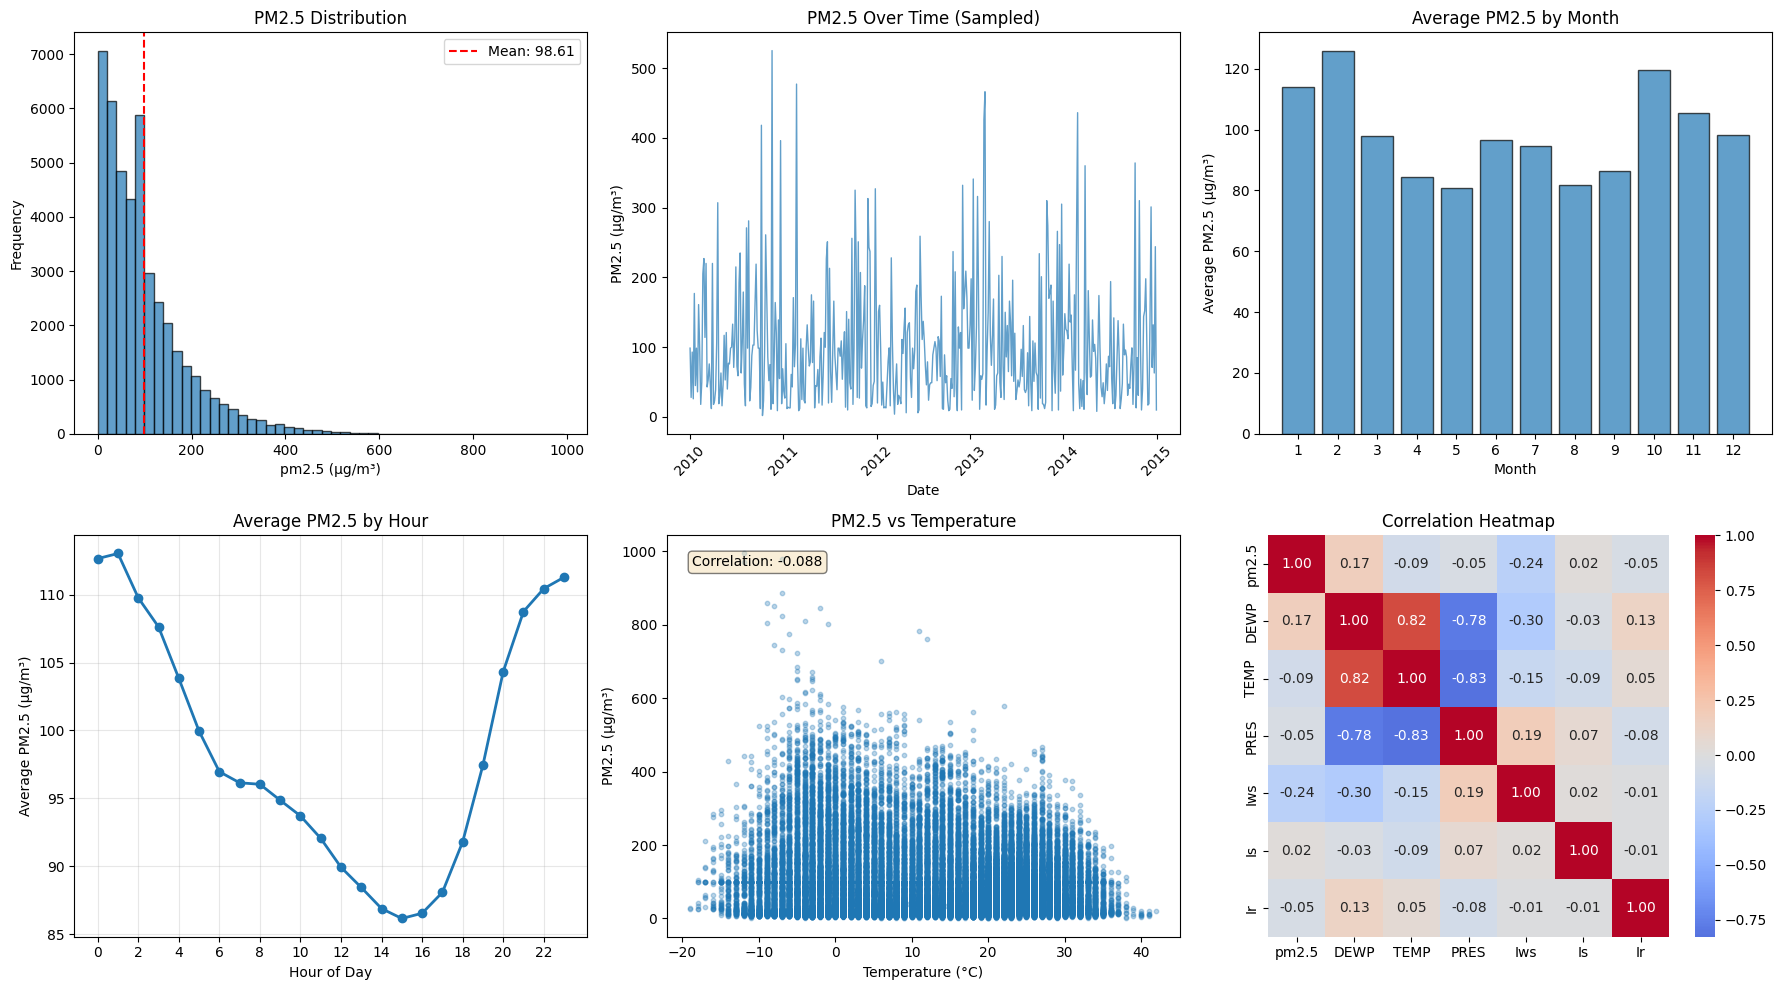

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

#Plot 1
axes[0, 0].hist(df_clean['pm2.5'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('pm2.5 (μg/m³)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('PM2.5 Distribution')
axes[0, 0].axvline(df_clean['pm2.5'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["pm2.5"].mean():.2f}')
axes[0, 0].legend()

#Plot 2
if 'datetime' in df_clean.columns:
    sample_data = df_clean.iloc[::100]  # Sample every 100th point
    axes[0, 1].plot(sample_data['datetime'], sample_data['pm2.5'], alpha=0.7, linewidth=1)
    axes[0, 1].set_xlabel('Date')
    axes[0, 1].set_ylabel('PM2.5 (μg/m³)')
    axes[0, 1].set_title('PM2.5 Over Time (Sampled)')
    axes[0, 1].tick_params(axis='x', rotation=45)

#Plot 3
if 'month' in df_clean.columns:
    monthly_avg = df_clean.groupby('month')['pm2.5'].mean()
    axes[0, 2].bar(monthly_avg.index, monthly_avg.values, alpha=0.7, edgecolor='black')
    axes[0, 2].set_xlabel('Month')
    axes[0, 2].set_ylabel('Average PM2.5 (μg/m³)')
    axes[0, 2].set_title('Average PM2.5 by Month')
    axes[0, 2].set_xticks(range(1, 13))

#Plot 4
if 'hour' in df_clean.columns:
    hourly_avg = df_clean.groupby('hour')['pm2.5'].mean()
    axes[1, 0].plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2)
    axes[1, 0].set_xlabel('Hour of Day')
    axes[1, 0].set_ylabel('Average PM2.5 (μg/m³)')
    axes[1, 0].set_title('Average PM2.5 by Hour')
    axes[1, 0].set_xticks(range(0, 24, 2))
    axes[1, 0].grid(True, alpha=0.3)

#Plot 5
if 'TEMP' in df_clean.columns:
    axes[1, 1].scatter(df_clean['TEMP'], df_clean['pm2.5'], alpha=0.3, s=10)
    axes[1, 1].set_xlabel('Temperature (°C)')
    axes[1, 1].set_ylabel('PM2.5 (μg/m³)')
    axes[1, 1].set_title('PM2.5 vs Temperature')

corr = df_clean['TEMP'].corr(df_clean['pm2.5'])
axes[1, 1].text(0.05, 0.95, f'Correlation: {corr:.3f}',
                    transform=axes[1, 1].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

#Plot 6
corr_cols = ['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir']
corr_cols = [col for col in corr_cols if col in df_clean.columns]
correlation_matrix = df_clean[corr_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1, 2], square=True)
axes[1, 2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

In [14]:
df_featured = df_clean.copy()

if 'datetime' in df_featured.columns:
    df_featured['day_of_week'] = df_featured['datetime'].dt.dayofweek
    df_featured['day_of_year'] = df_featured['datetime'].dt.dayofyear
    df_featured['week_of_year'] = df_featured['datetime'].dt.isocalendar().week
    df_featured['is_weekend'] = (df_featured['day_of_week'] >= 5).astype(int)

if 'month' in df_featured.columns:
    df_featured['season'] = df_featured['month'].map({
        12: 0, 1: 0, 2: 0,
        3: 1, 4: 1, 5: 1,
        6: 2, 7: 2, 8: 2,
        9: 3, 10: 3, 11: 3 })

df_featured['pm2.5_lag1'] = df_featured['pm2.5'].shift(1)
df_featured['pm2.5_lag24'] = df_featured['pm2.5'].shift(24)
df_featured['pm2.5_rolling_mean_24'] = df_featured['pm2.5'].rolling(window=24, min_periods=1).mean()
df_featured['pm2.5_rolling_std_24'] = df_featured['pm2.5'].rolling(window=24, min_periods=1).std()

if 'cbwd' in df_featured.columns:
    df_featured['wind_dir_encoded'] = pd.Categorical(df_featured['cbwd']).codes

df_featured = df_featured.dropna()
df_featured

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,...,day_of_week,day_of_year,week_of_year,is_weekend,season,pm2.5_lag1,pm2.5_lag24,pm2.5_rolling_mean_24,pm2.5_rolling_std_24,wind_dir_encoded
24,25,2010,1,2,0,129.0,-16,-4.0,1020.0,SE,...,5,2,53,1,0,98.613215,98.613215,99.879331,6.202677,2
25,26,2010,1,2,1,148.0,-15,-4.0,1020.0,SE,...,5,2,53,1,0,129.000000,98.613215,101.937113,11.604444,2
26,27,2010,1,2,2,159.0,-11,-5.0,1021.0,SE,...,5,2,53,1,0,148.000000,98.613215,104.453229,16.405774,2
27,28,2010,1,2,3,181.0,-7,-5.0,1022.0,SE,...,5,2,53,1,0,159.000000,98.613215,107.886012,22.585993,2
28,29,2010,1,2,4,138.0,-7,-5.0,1022.0,SE,...,5,2,53,1,0,181.000000,98.613215,109.527128,23.302502,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43819,43820,2014,12,31,19,8.0,-23,-2.0,1034.0,NW,...,2,365,1,0,0,10.000000,35.000000,11.291667,4.903230,1
43820,43821,2014,12,31,20,10.0,-22,-3.0,1034.0,NW,...,2,365,1,0,0,8.000000,26.000000,10.625000,3.774197,1
43821,43822,2014,12,31,21,10.0,-22,-3.0,1034.0,NW,...,2,365,1,0,0,10.000000,20.000000,10.208333,3.202976,1
43822,43823,2014,12,31,22,8.0,-22,-4.0,1034.0,NW,...,2,365,1,0,0,10.000000,8.000000,10.208333,3.202976,1


In [15]:
exclude_cols = ['pm2.5', 'datetime', 'No', 'year', 'month', 'day', 'hour', 'cbwd']
feature_columns = [col for col in df_featured.columns if col not in exclude_cols]

X = df_featured[feature_columns]
y = df_featured['pm2.5']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=20)
}

results = {}
for name, model in models.items():
    print(f"\n🔄 Training {name}...")



🔄 Training Linear Regression...

🔄 Training Random Forest...


In [17]:
if name == 'Linear Regression':
        model.fit(X_train_scaled, y_train)
        y_pred_train = model.predict(X_train_scaled)
        y_pred_test = model.predict(X_test_scaled)
else:
        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

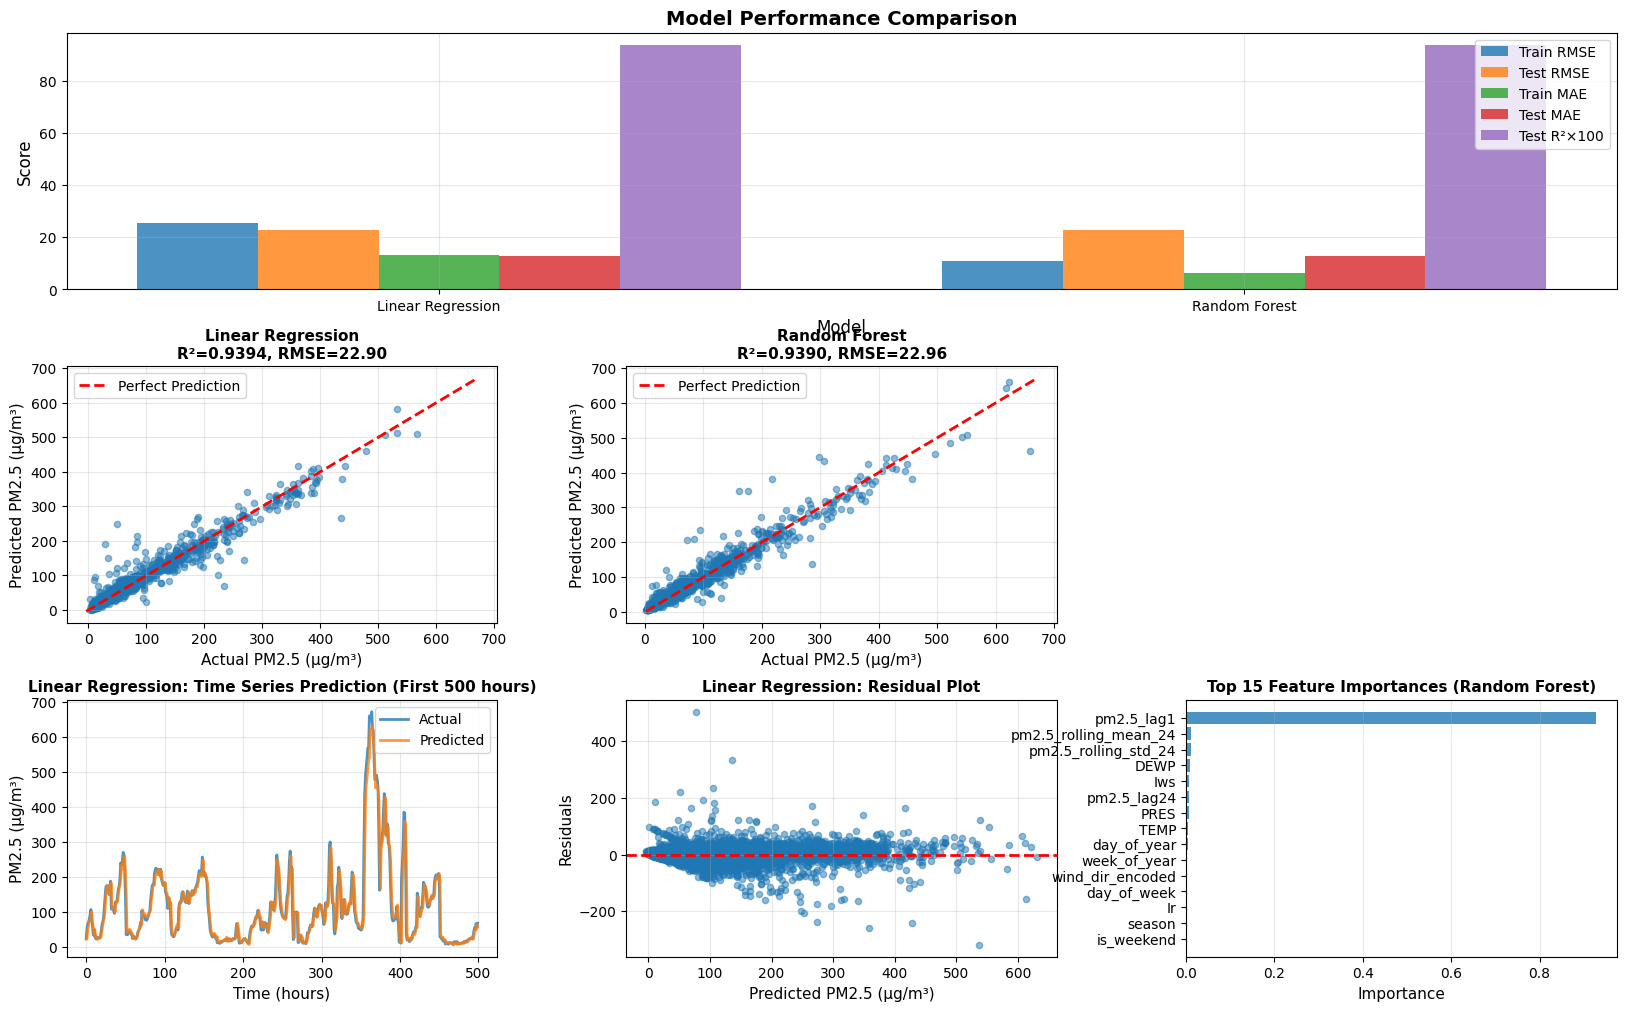

In [20]:
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Plot 1: Model Performance Comparison
ax1 = fig.add_subplot(gs[0, :])
metrics_data = []
for name in results.keys():
    metrics_data.append({
        'Model': name,
        'Train RMSE': results[name]['train_rmse'],
        'Test RMSE': results[name]['test_rmse'],
        'Train MAE': results[name]['train_mae'],
        'Test MAE': results[name]['test_mae'],
        'Train R²': results[name]['train_r2'],
        'Test R²': results[name]['test_r2']
    })

metrics_df = pd.DataFrame(metrics_data)
x = np.arange(len(metrics_df))
width = 0.15

ax1.bar(x - width*2, metrics_df['Train RMSE'], width, label='Train RMSE', alpha=0.8)
ax1.bar(x - width, metrics_df['Test RMSE'], width, label='Test RMSE', alpha=0.8)
ax1.bar(x, metrics_df['Train MAE'], width, label='Train MAE', alpha=0.8)
ax1.bar(x + width, metrics_df['Test MAE'], width, label='Test MAE', alpha=0.8)
ax1.bar(x + width*2, metrics_df['Test R²']*100, width, label='Test R²×100', alpha=0.8)

ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_df['Model'])
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Plots 2-3: Actual vs Predicted for each model
for idx, (name, result) in enumerate(results.items()):
    ax = fig.add_subplot(gs[1, idx])

    # Sample points for clearer visualization
    sample_indices = np.random.choice(len(y_test), min(1000, len(y_test)), replace=False)

    ax.scatter(y_test.iloc[sample_indices], result['test_predictions'][sample_indices],
              alpha=0.5, s=20)

    # Perfect prediction line
    min_val = min(y_test.min(), result['test_predictions'].min())
    max_val = max(y_test.max(), result['test_predictions'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

    ax.set_xlabel('Actual PM2.5 (μg/m³)', fontsize=11)
    ax.set_ylabel('Predicted PM2.5 (μg/m³)', fontsize=11)
    ax.set_title(f'{name}\nR²={result["test_r2"]:.4f}, RMSE={result["test_rmse"]:.2f}',
                fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Plot 4: Time series comparison (best model)
best_model_name = max(results.keys(), key=lambda x: results[x]['test_r2'])
best_predictions = results[best_model_name]['test_predictions']

ax4 = fig.add_subplot(gs[2, 0])
plot_range = slice(0, min(500, len(y_test)))
ax4.plot(y_test.iloc[plot_range].values, label='Actual', alpha=0.8, linewidth=2)
ax4.plot(best_predictions[plot_range], label='Predicted', alpha=0.8, linewidth=2)
ax4.set_xlabel('Time (hours)', fontsize=11)
ax4.set_ylabel('PM2.5 (μg/m³)', fontsize=11)
ax4.set_title(f'{best_model_name}: Time Series Prediction (First 500 hours)',
             fontsize=11, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Plot 5: Residuals plot
ax5 = fig.add_subplot(gs[2, 1])
residuals = y_test - best_predictions
ax5.scatter(best_predictions, residuals, alpha=0.5, s=20)
ax5.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax5.set_xlabel('Predicted PM2.5 (μg/m³)', fontsize=11)
ax5.set_ylabel('Residuals', fontsize=11)
ax5.set_title(f'{best_model_name}: Residual Plot', fontsize=11, fontweight='bold')
ax5.grid(True, alpha=0.3)

# Plot 6: Feature Importance (if Random Forest)
if 'Random Forest' in results:
    ax6 = fig.add_subplot(gs[2, 2])
    rf_model = results['Random Forest']['model']

    importance_df = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=True).tail(15)

    ax6.barh(importance_df['Feature'], importance_df['Importance'], alpha=0.8)
    ax6.set_xlabel('Importance', fontsize=11)
    ax6.set_title('Top 15 Feature Importances (Random Forest)', fontsize=11, fontweight='bold')
    ax6.grid(True, alpha=0.3, axis='x')

plt.show()


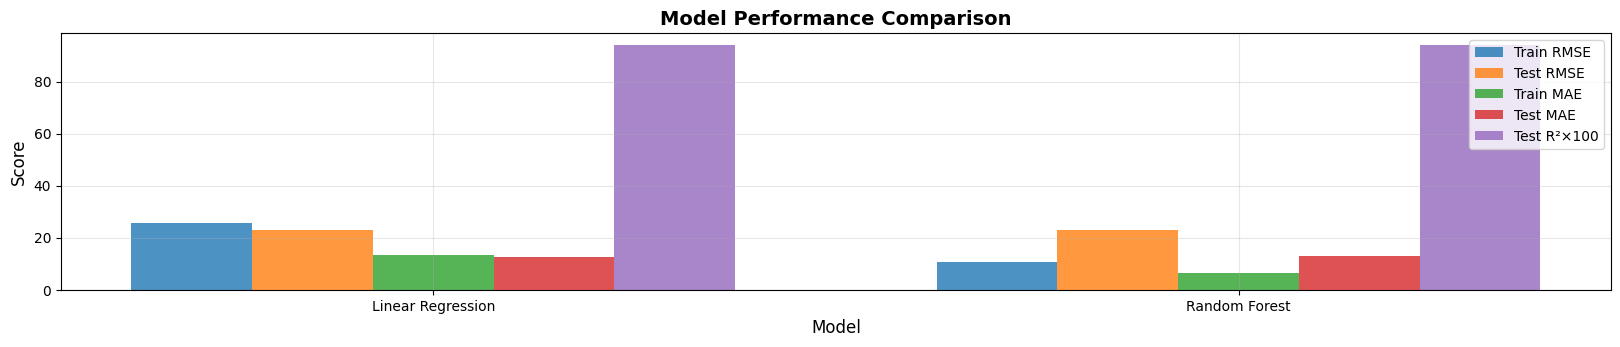

In [21]:
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :])
metrics_data = []
for name in results.keys():
    metrics_data.append({
        'Model': name,
        'Train RMSE': results[name]['train_rmse'],
        'Test RMSE': results[name]['test_rmse'],
        'Train MAE': results[name]['train_mae'],
        'Test MAE': results[name]['test_mae'],
        'Train R²': results[name]['train_r2'],
        'Test R²': results[name]['test_r2']
    })

metrics_df = pd.DataFrame(metrics_data)
x = np.arange(len(metrics_df))
width = 0.15

ax1.bar(x - width*2, metrics_df['Train RMSE'], width, label='Train RMSE', alpha=0.8)
ax1.bar(x - width, metrics_df['Test RMSE'], width, label='Test RMSE', alpha=0.8)
ax1.bar(x, metrics_df['Train MAE'], width, label='Train MAE', alpha=0.8)
ax1.bar(x + width, metrics_df['Test MAE'], width, label='Test MAE', alpha=0.8)
ax1.bar(x + width*2, metrics_df['Test R²']*100, width, label='Test R²×100', alpha=0.8)

ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_df['Model'])
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

plt.show()

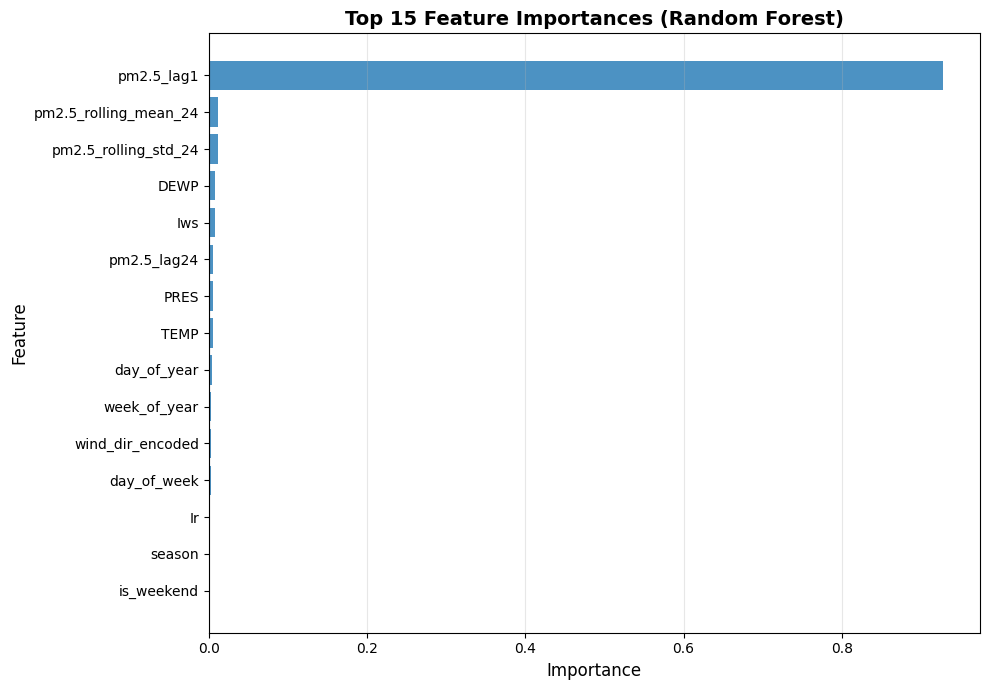

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

if 'Random Forest' in results:
    rf_model = results['Random Forest']['model']

    # Ensure feature_columns is accessible or re-define it if necessary
    # In this case, feature_columns should be available from a previous cell's execution

    importance_df = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=True).tail(15)

    plt.figure(figsize=(10, 7))
    plt.barh(importance_df['Feature'], importance_df['Importance'], alpha=0.8)
    plt.xlabel('Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.title('Top 15 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
else:
    print("Random Forest model not found in results.")

### Explanation of Evaluation Metrics:

1.  **Root Mean Squared Error (RMSE)**:
    *   **Meaning:** RMSE is the square root of the average of the squared differences between predicted values and actual values. It measures the average magnitude of the errors.
    *   **Interpretation:** A lower RMSE indicates a better fit of the model to the data. Because errors are squared before being averaged, RMSE gives a relatively high weight to large errors, meaning it is most useful when large errors are particularly undesirable.

2.  **Mean Absolute Error (MAE)**:
    *   **Meaning:** MAE is the average of the absolute differences between predicted values and actual values. It measures the average magnitude of the errors without considering their direction.
    *   **Interpretation:** A lower MAE indicates a better fit. MAE is more robust to outliers than RMSE because it does not square the errors.

3.  **R-squared (R²)**:
    *   **Meaning:** R-squared, also known as the coefficient of determination, represents the proportion of the variance in the dependent variable that is predictable from the independent variables. In simpler terms, it indicates how well the model explains the variability of the target variable.
    *   **Interpretation:** R² values range from 0 to 1 (or can be negative in some cases, indicating a very poor model). A higher R² value (closer to 1) means that a larger proportion of the variance is explained by the model, suggesting a better fit. An R² of 1 indicates that the model perfectly predicts the target variable, while an R² of 0 indicates that the model explains none of the variability of the target variable.

### Explanation of New Features:

1.  **`day_of_week`**:
    *   **Meaning:** Represents the day of the week (0 for Monday, 6 for Sunday).
    *   **Purpose:** Captures weekly patterns in PM2.5 levels. For example, pollution might vary between weekdays and weekends due to differences in human activity (e.g., traffic, industrial output).

2.  **`day_of_year`**:
    *   **Meaning:** Represents the day number within the year (1 for January 1st, up to 365/366).
    *   **Purpose:** Helps capture yearly cycles or trends that might influence air quality.

3.  **`week_of_year`**:
    *   **Meaning:** Represents the week number within the year.
    *   **Purpose:** Similar to `day_of_year` but provides a broader, weekly aggregation of time, useful for models to identify patterns that repeat on a weekly basis across years.

4.  **`is_weekend`**:
    *   **Meaning:** A binary feature (0 for weekday, 1 for weekend).
    *   **Purpose:** Directly highlights the distinction between weekdays and weekends, which often have different pollution patterns.

5.  **`season`**:
    *   **Meaning:** A categorical feature representing the season (0 for Winter, 1 for Spring, 2 for Summer, 3 for Autumn).
    *   **Purpose:** Air quality often varies significantly with seasons due to changes in weather patterns, temperature, precipitation, and human activities (e.g., heating in winter, agricultural burning).

6.  **`pm2.5_lag1`**:
    *   **Meaning:** The PM2.5 concentration from the previous hour (`shift(1)`).
    *   **Purpose:** Incorporates the immediate past PM2.5 value, as air pollution is highly autocorrelated (current levels are strongly dependent on recent past levels). This acts as a short-term trend indicator.

7.  **`pm2.5_lag24`**:
    *   **Meaning:** The PM2.5 concentration from 24 hours ago (`shift(24)`).
    *   **Purpose:** Captures daily periodicity. Air pollution often follows a daily cycle, and knowing the PM2.5 level at the same time yesterday can be a strong predictor for the current hour.

8.  **`pm2.5_rolling_mean_24`**:
    *   **Meaning:** The average PM2.5 concentration over the past 24 hours.
    *   **Purpose:** Provides a smoothed trend of PM2.5, helping the model understand the general pollution level over a day, reducing noise from hourly fluctuations.

9.  **`pm2.5_rolling_std_24`**:
    *   **Meaning:** The standard deviation of PM2.5 concentration over the past 24 hours.
    *   **Purpose:** Measures the variability or volatility of PM2.5 levels over the past day. High variability might indicate sudden changes in air quality.

10. **`wind_dir_encoded`**:
    *   **Meaning:** A numerical representation of the wind direction (`cbwd`) obtained by one-hot encoding categorical wind direction values.
    *   **Purpose:** Wind direction is a critical meteorological factor influencing air pollution dispersion and transport. Encoding it allows the model to use this directional information.

In [19]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=20)
}

results = {}
for name, model in models.items():
    print(f"\n🔄 Training {name}...")

    if name == 'Linear Regression':
        model.fit(X_train_scaled, y_train)
        y_pred_train = model.predict(X_train_scaled)
        y_pred_test = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    train_mae = mean_absolute_error(y_train, y_pred_train)
    train_r2 = r2_score(y_train, y_pred_train)

    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_r2 = r2_score(y_test, y_pred_test)

    results[name] = {
        'model': model,
        'train_predictions': y_pred_train,
        'test_predictions': y_pred_test,
        'train_rmse': train_rmse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'test_r2': test_r2
    }

    print(f"✓ {name} trained successfully!")
    print(f"\n  Training Metrics:")
    print(f"    RMSE: {train_rmse:.2f} μg/m³")
    print(f"    MAE:  {train_mae:.2f} μg/m³")
    print(f"    R²:   {train_r2:.4f}")
    print(f"\n  Testing Metrics:")
    print(f"    RMSE: {test_rmse:.2f} μg/m³")
    print(f"    MAE:  {test_mae:.2f} μg/m³")
    print(f"    R²:   {test_r2:.4f}")

lr_results = results['Linear Regression']
rf_results = results['Random Forest']

comparison_df = pd.DataFrame({
    'Metric': ['Train RMSE', 'Test RMSE', 'Train MAE', 'Test MAE', 'Train R²', 'Test R²'],
    'Linear Regression': [
        lr_results['train_rmse'], lr_results['test_rmse'],
        lr_results['train_mae'], lr_results['test_mae'],
        lr_results['train_r2'], lr_results['test_r2']
    ],
    'Random Forest': [
        rf_results['train_rmse'], rf_results['test_rmse'],
        rf_results['train_mae'], rf_results['test_mae'],
        rf_results['train_r2'], rf_results['test_r2']
    ]
})
comparison_df['Difference'] = comparison_df['Random Forest'] - comparison_df['Linear Regression']
comparison_df['Winner'] = comparison_df.apply(
    lambda row: 'Random Forest' if (row['Difference'] < 0 and 'RMSE' in row['Metric']) or
                                    (row['Difference'] < 0 and 'MAE' in row['Metric']) or
                                    (row['Difference'] > 0 and 'R²' in row['Metric'])
                else 'Linear Regression',
    axis=1
)

print("\n", comparison_df.to_string(index=False))


🔄 Training Linear Regression...
✓ Linear Regression trained successfully!

  Training Metrics:
    RMSE: 25.70 μg/m³
    MAE:  13.37 μg/m³
    R²:   0.9167

  Testing Metrics:
    RMSE: 22.90 μg/m³
    MAE:  12.65 μg/m³
    R²:   0.9394

🔄 Training Random Forest...
✓ Random Forest trained successfully!

  Training Metrics:
    RMSE: 10.73 μg/m³
    MAE:  6.24 μg/m³
    R²:   0.9855

  Testing Metrics:
    RMSE: 22.96 μg/m³
    MAE:  12.96 μg/m³
    R²:   0.9390

     Metric  Linear Regression  Random Forest  Difference            Winner
Train RMSE          25.702702      10.729735  -14.972966     Random Forest
 Test RMSE          22.901601      22.964545    0.062944 Linear Regression
 Train MAE          13.367437       6.242164   -7.125273     Random Forest
  Test MAE          12.653024      12.961296    0.308271 Linear Regression
  Train R²           0.916745       0.985491    0.068746     Random Forest
   Test R²           0.939354       0.939020   -0.000334 Linear Regression
